[*********************100%***********************]  1 of 1 completed

Fetching SPY daily log-prices...


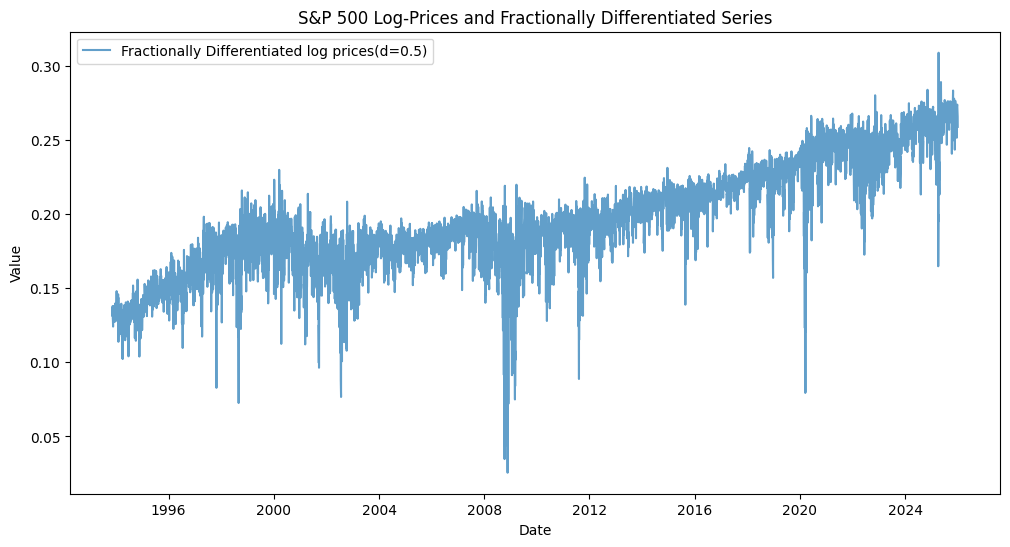

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.feature_selection import mutual_info_regression
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

def get_ffd_weights(d: float, thres: float) -> np.ndarray:
    """Generates fractional differentiation weights up to a threshold."""
    w, k = [1.], 1
    while True:
        w_ = -w[-1] / k * (d - k + 1)
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

def frac_diff_ffd(series: pd.Series, d: float, thres: float = 1e-4) -> pd.Series:
    """Applies Fractional Differentiation (Fixed-Window) to a Pandas Series."""
    w = get_ffd_weights(d, thres)
    width = len(w) - 1
    df_ = pd.Series(index=series.index, dtype=float)
    
    # Vectorized dot product over a rolling window
    for i in range(width, len(series)):
        window = series.iloc[i - width : i + 1].values
        if np.isfinite(window).all():
            df_.iloc[i] = np.dot(w.T, window)[0]
            
    return df_.dropna()

# 1. Fetch Data
print("Fetching SPY daily log-prices...")
data = yf.download(['SPY'], start='1990-01-01', end='2026-01-01', auto_adjust=False)['Adj Close']
log_prices = np.log(data).dropna()
prices = data.dropna()

diff_log_prices = frac_diff_ffd(log_prices['SPY'], d=0.5)
diff_log_prices = diff_log_prices


plt.figure(figsize=(12, 6))
plt.plot(diff_log_prices.index, diff_log_prices.values, label='Fractionally Differentiated log prices(d=0.5)', alpha=0.7)
plt.title('S&P 500 Log-Prices and Fractionally Differentiated Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


Queremos minimizar el _d_ tal que la serie sea estacionaria manteniendo algo de memoria. Para ello calculamos la correlacion de pearson entre la serie de precios vs la serie diferenciada, para distintos d. Simultáneamente se grafica el valor del p-value.

     d    adf_pvalue  pearson_corr  n_obs
0  0.0  9.611193e-01      1.000000   8288
1  0.1  9.123367e-01      0.998751   7786
2  0.2  8.148657e-01      0.992907   7792
3  0.3  6.333980e-01      0.981484   7901
4  0.4  3.545495e-01      0.960108   8007
5  0.5  1.410844e-01      0.917243   8089
6  0.6  2.842383e-02      0.833171   8149
7  0.7  1.186770e-03      0.688805   8192
8  0.8  3.644938e-06      0.496885   8225
9  0.9  1.311671e-11      0.290387   8251


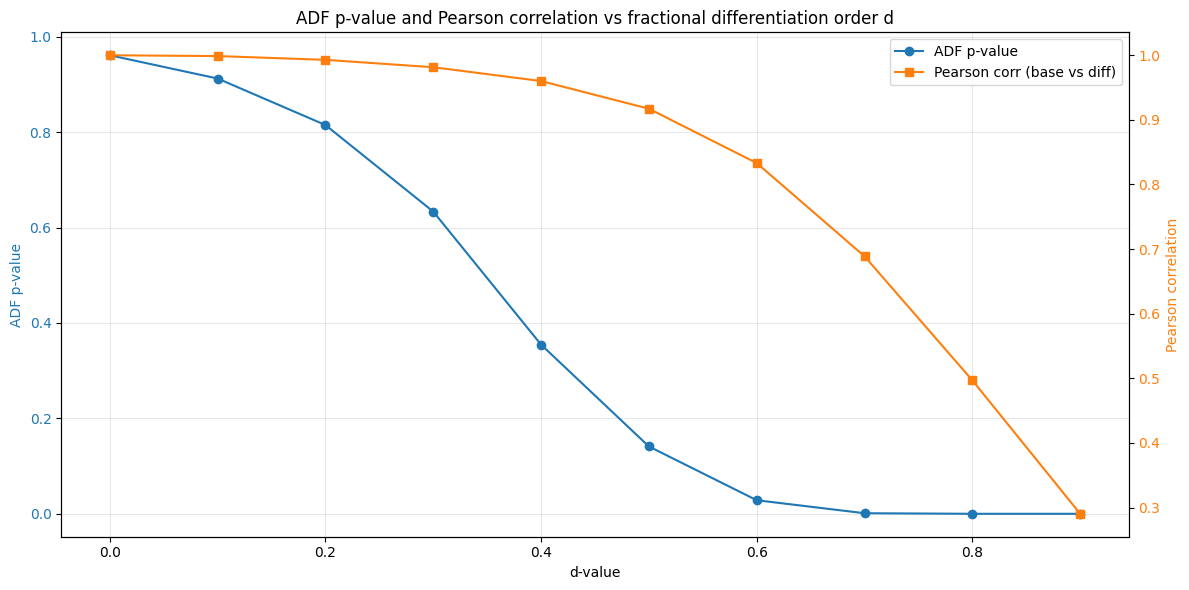

In [3]:
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller

# Use the same base series used for fractional differentiation
base_series = log_prices['SPY']

# Grid of differentiation orders
# You can increase resolution (e.g., step=0.05) if needed
d_values = np.round(np.arange(0.0, 1.00, 0.1), 2)

results = []

for d in d_values:
    diff_series = frac_diff_ffd(base_series, d=d, thres=1e-4)

    # Align on common dates to compare both series consistently
    aligned_base = base_series.reindex(diff_series.index).dropna()
    aligned_diff = diff_series.reindex(aligned_base.index).dropna()

    # Re-align in case of any residual NaNs
    aligned_base = aligned_base.reindex(aligned_diff.index)

    if len(aligned_diff) < 10:
        adf_pvalue = np.nan
        pearson_corr = np.nan
    else:
        adf_pvalue = adfuller(aligned_diff)[1]
        pearson_corr = pearsonr(aligned_base, aligned_diff)[0]

    results.append({
        'd': d,
        'adf_pvalue': adf_pvalue,
        'pearson_corr': pearson_corr,
        'n_obs': len(aligned_diff)
    })

results_df = pd.DataFrame(results)
print(results_df)

fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = ax1.plot(results_df['d'], results_df['adf_pvalue'], marker='o', color='tab:blue', label='ADF p-value')
ax1.set_xlabel('d-value')
ax1.set_ylabel('ADF p-value', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
line2 = ax2.plot(results_df['d'], results_df['pearson_corr'], marker='s', color='tab:orange', label='Pearson corr (base vs diff)')
ax2.set_ylabel('Pearson correlation', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title('ADF p-value and Pearson correlation vs fractional differentiation order d')
plt.tight_layout()
plt.show()

d=0.3, T=252: stat=-2.1851, p=0.211696, windows=365
d=0.3, T=504: stat=-3.1938, p=0.020346, windows=353
d=0.3, T=756: stat=-2.4868, p=0.118722, windows=341
d=0.3, T=1008: stat=-1.9750, p=0.297623, windows=329
d=0.3, T=1260: stat=-2.3185, p=0.166071, windows=317
d=0.3, T=2520: stat=-1.9275, p=0.319231, windows=257
d=0.32, T=252: stat=-2.3291, p=0.162757, windows=366
d=0.32, T=504: stat=-3.4142, p=0.010483, windows=354
d=0.32, T=756: stat=-2.8582, p=0.050426, windows=342
d=0.32, T=1008: stat=-2.1896, p=0.210057, windows=330
d=0.32, T=1260: stat=-2.5655, p=0.100337, windows=318
d=0.32, T=2520: stat=-2.0754, p=0.254514, windows=258
d=0.34, T=252: stat=-2.4824, p=0.119809, windows=367
d=0.34, T=504: stat=-3.6251, p=0.005298, windows=355
d=0.34, T=756: stat=-2.9337, p=0.041568, windows=343
d=0.34, T=1008: stat=-2.3968, p=0.142647, windows=331
d=0.34, T=1260: stat=-2.7955, p=0.058914, windows=319
d=0.34, T=2520: stat=-2.1893, p=0.210162, windows=259
d=0.36, T=252: stat=-2.6115, p=0.090648, wi

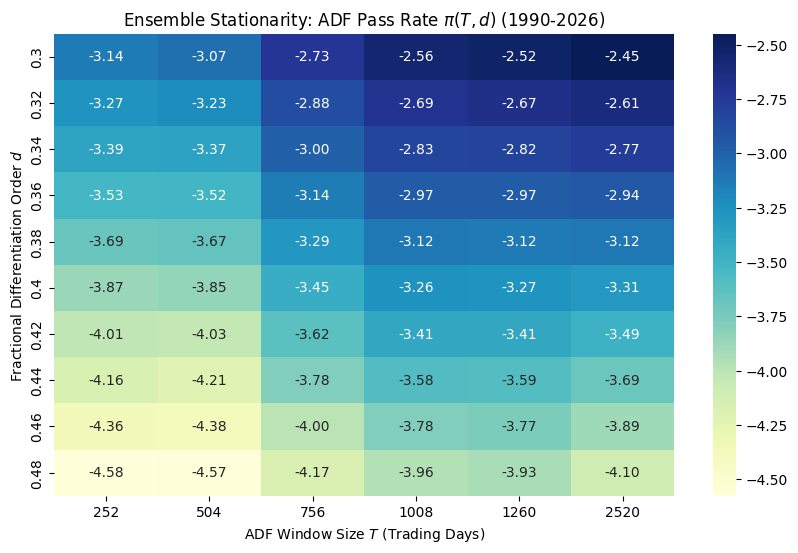

In [8]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def get_weights_ffd(d, thres=1e-4):
    """Calculate FFD weights."""
    w = [1.]
    k = 1
    while abs(w[-1]) >= thres:
        w_new = -w[-1] / k * (d - k + 1)
        w.append(w_new)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

def frac_diff_ffd(series, d, thres=1e-4):
    w = get_weights_ffd(d, thres)
    width = len(w) - 1
    df = {}
    for name in series.columns:
        seriesF = series[[name]].ffill().dropna()  # Fix Bug 2
        df_ = pd.Series(dtype=float)
        for iloc1 in range(width, seriesF.shape[0]):
            loc0 = seriesF.index[iloc1 - width]
            loc1 = seriesF.index[iloc1]
            slice_ = seriesF.loc[loc0:loc1]
            if len(slice_) != len(w):             # Fix Bug 4
                continue
            if not np.isfinite(slice_[name]).all(): # Fix Bug 3
                continue
            df_[loc1] = np.dot(w.T, slice_)[0, 0]
        df[name] = df_.copy(deep=True)
    return pd.concat(df, axis=1)


# --- 1. Define the Grid ---
# Assume `log_prices` is a pandas DataFrame with your 1990-2026 data
d_values = np.round(np.arange(0.3, 0.5, 0.02), 2)
# T in trading days: 1 yr, 2 yrs, 3 yrs, 4 yrs, 5 yrs, 10 yrs
T_values = [252, 504, 756, 1008, 1260, 2520] 
step_size = 21 # Sample a window every 1 month to save compute time

results_matrix = np.zeros((len(d_values), len(T_values)))

# --- 2. Compute Ensemble Stationarity ---
for i, d in enumerate(d_values):
    diff_series = frac_diff_ffd(log_prices, d=d).dropna().iloc[:, 0]

    for j, T in enumerate(T_values):
        adf_sum = 0
        total_windows = 0

        for start_idx in range(0, len(diff_series) - T, step_size):
            window_data = diff_series.iloc[start_idx:start_idx + T]
            if window_data.std() < 1e-8:
                continue
            adf_stat, p_val, *_ = adfuller(window_data)
            adf_sum += adf_stat
            total_windows += 1

        print(f"d={d}, T={T}: stat={adf_stat:.4f}, p={p_val:.6f}, windows={total_windows}")
        results_matrix[i, j] = adf_sum / total_windows if total_windows > 0 else 0

# --- 3. Plot the Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(results_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
            xticklabels=T_values, yticklabels=d_values)
plt.title("Ensemble Stationarity: ADF Pass Rate $\pi(T, d)$ (1990-2026)")
plt.xlabel("ADF Window Size $T$ (Trading Days)")
plt.ylabel("Fractional Differentiation Order $d$")
plt.show()

d=0.30, T=252: mean_corr=0.7770, windows=365
d=0.30, T=504: mean_corr=0.7879, windows=353
d=0.30, T=756: mean_corr=0.8104, windows=341
d=0.30, T=1008: mean_corr=0.8351, windows=329
d=0.30, T=1260: mean_corr=0.8512, windows=317
d=0.30, T=2520: mean_corr=0.8867, windows=257
d=0.32, T=252: mean_corr=0.7512, windows=366
d=0.32, T=504: mean_corr=0.7615, windows=354
d=0.32, T=756: mean_corr=0.7851, windows=342
d=0.32, T=1008: mean_corr=0.8114, windows=330
d=0.32, T=1260: mean_corr=0.8292, windows=318
d=0.32, T=2520: mean_corr=0.8697, windows=258
d=0.34, T=252: mean_corr=0.7246, windows=367
d=0.34, T=504: mean_corr=0.7342, windows=355
d=0.34, T=756: mean_corr=0.7585, windows=343
d=0.34, T=1008: mean_corr=0.7862, windows=331
d=0.34, T=1260: mean_corr=0.8056, windows=319
d=0.34, T=2520: mean_corr=0.8514, windows=259
d=0.36, T=252: mean_corr=0.6976, windows=368
d=0.36, T=504: mean_corr=0.7062, windows=356
d=0.36, T=756: mean_corr=0.7309, windows=344
d=0.36, T=1008: mean_corr=0.7596, windows=332


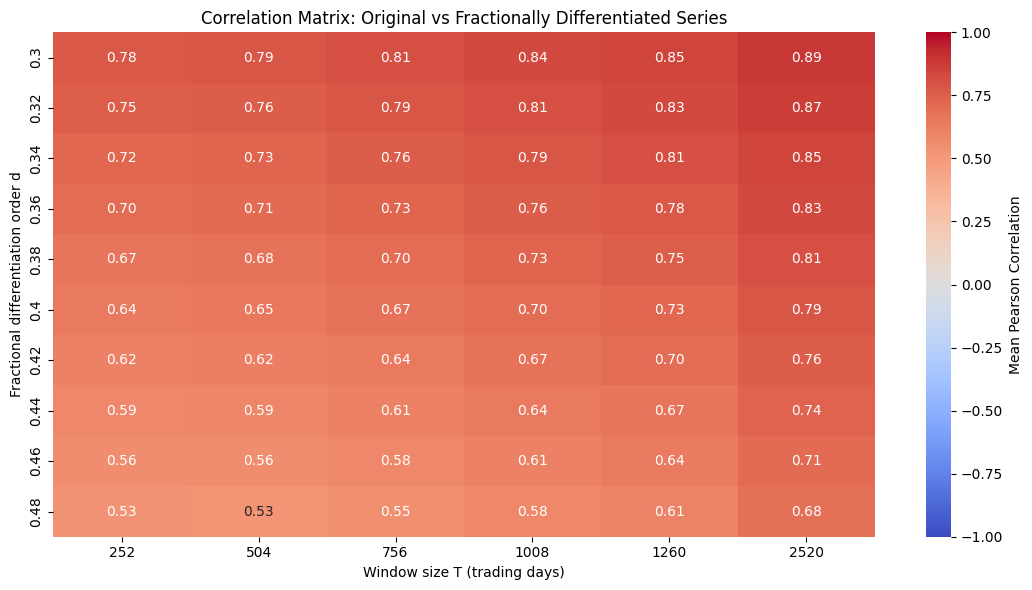

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Base/original series
base_series = log_prices["SPY"] if isinstance(log_prices, pd.DataFrame) else log_prices.squeeze()

# Reuse grid if already defined above; otherwise set defaults
if "d_values" not in globals():
    d_values = np.round(np.arange(0.1, 1.05, 0.1), 2)
if "T_values" not in globals():
    T_values = [252, 504, 756, 1008, 1260, 2520]

window_step = step_size if "step_size" in globals() else 21

corr_matrix = np.full((len(d_values), len(T_values)), np.nan)

for i, d in enumerate(d_values):
    # Fractionally differentiated series for this d
    diff_series = frac_diff_ffd(log_prices, d=d).dropna().iloc[:, 0]

    # Align base and differentiated series on common dates
    aligned_base = base_series.reindex(diff_series.index).dropna()
    aligned_diff = diff_series.reindex(aligned_base.index).dropna()
    aligned_base = aligned_base.reindex(aligned_diff.index)

    for j, T in enumerate(T_values):
        corr_values = []

        if len(aligned_diff) < T:
            continue

        # Compute rolling-window correlations for this horizon T
        for start_idx in range(0, len(aligned_diff) - T + 1, window_step):
            window_base = aligned_base.iloc[start_idx:start_idx + T]
            window_diff = aligned_diff.iloc[start_idx:start_idx + T]

            if window_base.std() < 1e-12 or window_diff.std() < 1e-12:
                continue

            corr_values.append(np.corrcoef(window_base.values, window_diff.values)[0, 1])

        if corr_values:
            corr_matrix[i, j] = np.nanmean(corr_values)

        print(
            f"d={d:.2f}, T={T}: mean_corr={corr_matrix[i, j]:.4f}, windows={len(corr_values)}"
        )

corr_df = pd.DataFrame(corr_matrix, index=d_values, columns=T_values)
print("\nCorrelation matrix (mean rolling Pearson corr):")
print(corr_df)

plt.figure(figsize=(11, 6))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Mean Pearson Correlation"},
)
plt.title("Correlation Matrix: Original vs Fractionally Differentiated Series")
plt.xlabel("Window size T (trading days)")
plt.ylabel("Fractional differentiation order d")
plt.tight_layout()
plt.show()